In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import time

df = pd.read_csv('Dataset_1.csv')

In [8]:
features = ['Study_Hours_Per_Day', 'Attendance_Percentage']
target = 'Final_Exam_Score_100'

df_clean = df.dropna(subset=features + [target]).copy()

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
start_time_ols = time.time()
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
ols_time = time.time() - start_time_ols

y_pred_ols = ols_model.predict(X_test_scaled)
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

In [11]:
start_time_gd = time.time()
gd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
gd_model.fit(X_train_scaled, y_train)
gd_time = time.time() - start_time_gd

y_pred_gd = gd_model.predict(X_test_scaled)
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

In [12]:
results = pd.DataFrame({
    'Model': ['Ordinary Least Squares (OLS)', 'Gradient Descent (SGD)'],
    'MSE': [mse_ols, mse_gd],
    'R2 Score': [r2_ols, r2_gd],
    'Time Taken (seconds)': [ols_time, gd_time]
})

print(results)

                          Model        MSE  R2 Score  Time Taken (seconds)
0  Ordinary Least Squares (OLS)  84.308585  0.218017              2.384895
1        Gradient Descent (SGD)  84.588085  0.215425              0.394204


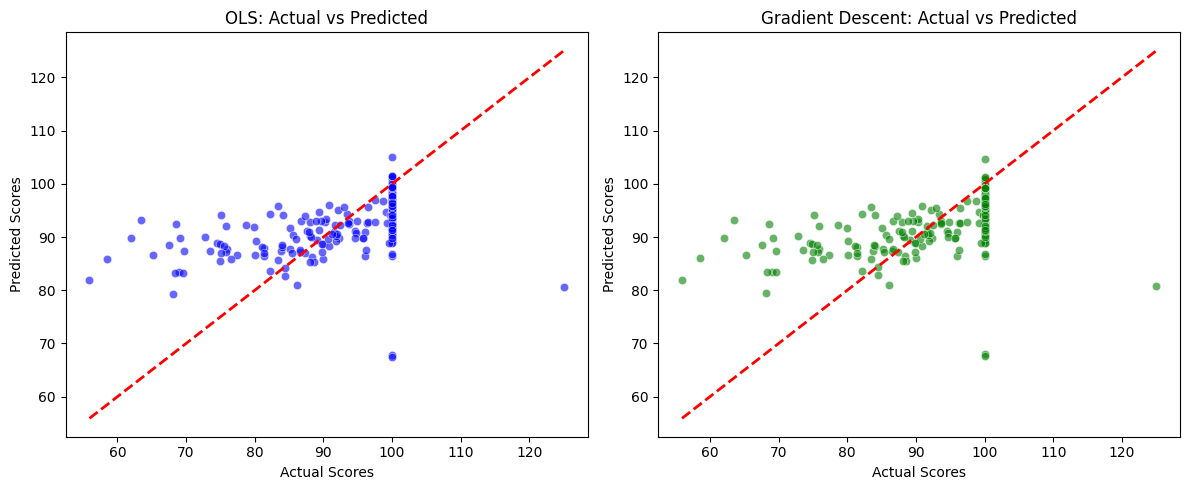

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_ols, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("OLS: Actual vs Predicted")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_gd, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Gradient Descent: Actual vs Predicted")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.tight_layout()
plt.show()